In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
from matplotlib.pyplot import GridSpec

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [3]:
# data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [4]:
# # get names of all images in dataset_dir/images
# image_names = os.listdir(f"{DATASET_DIR}/images")

# count_images = len(image_names)

In [5]:
# count_images

In [6]:
# # sort image names based on number in name name format is : image_number.png
# image_names.sort(key=lambda x: int(x.split(".")[0].split("_")[1]))

In [7]:
# image_names[-5:]

In [8]:
# label_mapping = {
#     'Benign': 'Benign',
#     'Bot': 'Botnet',
#     'FTP-BruteForce': 'Brute Force',
#     'SSH-Bruteforce': 'Brute Force',
#     'DDoS attacks-LOIC-HTTP': 'DDoS',
#     'DDOS attack-LOIC-UDP': 'DDoS',
#     'DDOS attack-HOIC': 'DDoS',
#     'DoS attacks-GoldenEye': 'DoS',
#     'DoS attacks-Slowloris': 'DoS',
#     'DoS attacks-SlowHTTPTest': 'DoS',
#     'DoS attacks-Hulk': 'DoS',
#     'Infilteration': 'Infiltration',
#     'Brute Force -Web': 'Brute Force',
#     'Brute Force -XSS': 'Brute Force',
#     'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
# }

# data["Label"] = data["Label"].map(label_mapping)

In [9]:
# data["Label"].value_counts()

In [10]:
# data.tail()

In [11]:
# train_data = data.groupby("Label").sample(5000, random_state=42)
# train_data.head()

In [12]:
# train_data_index = train_data.index
# train_data_index

In [13]:
# remaining_data = data[~data.index.isin(train_data_index)]
# remaining_data.head()

In [14]:
# remaining_data["Label"].value_counts()

In [15]:
# # get data for validation and test
# # test data size should be 10k
# val_data = remaining_data.groupby("Label").sample(5000, random_state=42)

# val_data_index = val_data.index

# val_data["Label"].value_counts()

In [16]:
# test_data = remaining_data[~remaining_data.index.isin(val_data_index)]

# test_data["Label"].value_counts()

In [17]:
# def clean_image_path(image_path):
#     return os.path.basename(image_path)

# # store images and labels in a dataframe
# def store_images_and_labels(data_index, bin_labels, datatype):
#     images = []
#     labels = []

#     images_dir = f"{DATASET_DIR}/images"

#     for index in data_index:
#         image_path = f"{images_dir}/image_{index}.png"
#         images.append(image_path)
#         labels.append(bin_labels[index])

#     df = pd.DataFrame({
#         "Image": images,
#         "Label": labels
#     })


#     df["Image"] = df["Image"].apply(clean_image_path)

#     df.to_csv(f"{DATASET_DIR}/{datatype}.csv", index=False)

#     return df

# # images = []
# # labels = []

# # images_dir = f"{DATASET_DIR}/images"

# # with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
# #     all_labels = pickle.load(f)

# # for index in train_data_index:
# #     # images are grayscale, with mode L
# #     image_path = f"{images_dir}/image_{index}.png"
# #     images.append(image_path)
# #     labels.append(all_labels[index])


# # train_df = pd.DataFrame({
# #     "Image": images,
# #     "Label": labels
# # })


# with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
#     all_labels = pickle.load(f)


# train_df = store_images_and_labels(train_data_index, all_labels, "train")

In [18]:
# val_df = store_images_and_labels(val_data_index, all_labels, "val")
# test_df = store_images_and_labels(test_data.index, all_labels, "test")

In [19]:
train_df = pd.read_csv(f"{DATASET_DIR}/train.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test.csv")

In [20]:
train_df["Label"].value_counts()

Label
Malicious    25000
Benign        5000
Name: count, dtype: int64

In [21]:
# verify the images in train are not in val or test
train_images = set(train_df["Image"])
val_images = set(val_df["Image"])
test_images = set(test_df["Image"])

assert len(train_images.intersection(val_images)) == 0
assert len(train_images.intersection(test_images)) == 0

# verify the images in val are not in test
assert len(val_images.intersection(test_images)) == 0

In [22]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [23]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,1
1,image_2975672.png,1
2,image_6489183.png,1
3,image_2675390.png,1
4,image_5559062.png,1


In [24]:

# Keep validation transforms simple - just basic preprocessing
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [25]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [26]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [65]:
class BinaryCNN2(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN2, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
            
        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 2 * 2 , 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, num_classes)
            # nn.ReLU(),
            # nn.Dropout(0.2),

            # nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

class BinaryCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding="same"),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
            
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

class BinaryCNN3(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN3, self).__init__()
        
        # Feature extraction layers
        self.conv1 = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
        )

        self.conv2 = nn.Sequential(
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        # print(x.shape)
        x = self.conv2(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

class BinaryCNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  # Single output for binary classification
        )

    def forward(self, x):
        x = self.features(x)

        # print(x.shape)

        x = torch.flatten(x, 1)

        # print(x.shape)

        return self.classifier(x)

In [66]:
dummy = torch.randn(1, 1, 32, 32)
model = BinaryCNN3()
model(dummy)

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 128])

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_cross_entropy = nn.CrossEntropyLoss
criterion_logits = nn.BCEWithLogitsLoss

In [68]:
# calculate metrics for binary classification
# accuracy, precision, recall, f1 score
# use sklearn to calculate these metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="micro")
    recall = recall_score(y_true, y_pred, average="micro")
    f1 = f1_score(y_true, y_pred, average="micro")
    
    return accuracy, precision, recall, f1

def calculate_class_metrics(y_true, y_pred):
    """Calculate metrics for each class separately."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


    overall_accuracy = accuracy_score(y_true, y_pred)

    benign_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0
    malicious_accuracy = tn / (tn + fp) if (tn + fp) > 0 else 0

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'overall_accuracy': overall_accuracy,
        'benign': {
            'accuracy': benign_accuracy,
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'accuracy': malicious_accuracy,
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [62]:
def train_model_reduceonplateau(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class().to(device)
    
    if loss_class == nn.BCEWithLogitsLoss:
        if pos_weights is not None:
            criterion = loss_class(pos_weight=pos_weights)
        elif weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    elif loss_class == nn.CrossEntropyLoss:
        if weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    else:
        criterion = loss_class()


    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.999))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "benign_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        },
        "malicious_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []  # Added to store probabilities

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)
            
            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            outputs = outputs.squeeze(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if loss_class == nn.CrossEntropyLoss:
                probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = (probs > 0.5).astype(int)


            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)  # Store probabilities

        train_loss /= len(train_dataloader)
        train_metrics = calculate_class_metrics(train_true, train_preds)

        # Validation phase
        # model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []  # Added to store probabilities

        with torch.no_grad():
            model.eval()


            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)
                outputs = outputs.squeeze(-1)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                if loss_class == nn.CrossEntropyLoss:
                    probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = (probs > 0.5).astype(int)
                    
                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)  # Store probabilities

        val_loss /= len(val_dataloader)
        val_metrics = calculate_class_metrics(val_true, val_preds)
        

        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
            history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
            history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
            history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

        if debug:
            # Print metrics
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print("\nBenign Metrics:")
            print(f"Train - Accuracy: {train_metrics['benign']['accuracy']:.4f}, Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['benign']['accuracy']:.4f}, Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
            print("\nMalicious Metrics:")
            print(f"Train - Accuracy: {train_metrics['malicious']['accuracy']:.4f}, Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['malicious']['accuracy']:.4f}, Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")
        else:
            # Print loss and overall accuracy
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['overall_accuracy']:.4f}, Val: {val_metrics['overall_accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            if model_savepath:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': val_loss,
                    'scheduler_state_dict': scheduler.state_dict(),
                    'learning_rate': scheduler.get_last_lr(),
                    'history': history
                }, model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        scheduler.step(val_loss)

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [63]:
def train_model_cosine(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class().to(device)
    
    # Corrected loss initialization
    if loss_class == nn.BCEWithLogitsLoss:
        if pos_weights is not None:
            criterion = loss_class(pos_weight=pos_weights)
        elif weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    elif loss_class == nn.CrossEntropyLoss:
        if weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    else:
        criterion = loss_class()

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Cosine scheduler (now properly initialized)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=num_epochs,
        eta_min=0.0
    )

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "benign_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        },
        "malicious_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)

            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)

            outputs = outputs.squeeze(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Corrected probability and prediction calculation
            if loss_class == nn.CrossEntropyLoss:
                probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = (probs > 0.5).astype(int)  # Fixed thresholding

            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)

        # Move scheduler step outside batch loop
        scheduler.step()
        train_loss /= len(train_dataloader)
        train_metrics = calculate_class_metrics(train_true, train_preds)

        # Validation phase
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []

        with torch.no_grad():
            model.eval()
            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)

                outputs = outputs.squeeze(-1)


                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Corrected validation probabilities
                if loss_class == nn.CrossEntropyLoss:
                    probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = (probs > 0.5).astype(int)  # Fixed thresholding

                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)

        val_loss /= len(val_dataloader)
        val_metrics = calculate_class_metrics(val_true, val_preds)
        
        # Rest of the code remains the same as your reduceonplateau version...
        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
            history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
            history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
            history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

        if debug:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print("\nBenign Metrics:")
            print(f"Train - Accuracy: {train_metrics['benign']['accuracy']:.4f}, Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['benign']['accuracy']:.4f}, Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
            print("\nMalicious Metrics:")
            print(f"Train - Accuracy: {train_metrics['malicious']['accuracy']:.4f}, Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['malicious']['accuracy']:.4f}, Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")
        else:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['overall_accuracy']:.4f}, Val: {val_metrics['overall_accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            if model_savepath:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': val_loss,
                    'scheduler_state_dict': scheduler.state_dict(),
                    'learning_rate': scheduler.get_last_lr(),
                    'history': history
                }, model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [33]:
def plot_metrics(history):
    gs = GridSpec(2, 2)
    fig = plt.figure(figsize=(12, 12))

    ax = [
        [fig.add_subplot(gs[0, :])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    ]



    # Loss
    ax[0][0].plot(history["train_loss"], label="Train Loss")
    ax[0][0].plot(history["val_loss"], label="Val Loss")
    ax[0][0].set_title("Loss")
    # ax[0][0].set_ylim(
    ax[0][0].legend()


    # Accuracy
    ax[1][0].plot(history["benign_metrics"]["train"]["accuracy"], label="Train Accuracy")
    ax[1][0].plot(history["benign_metrics"]["val"]["accuracy"], label="Val Accuracy")
    ax[1][0].set_title("Benign Accuracy")
    # ax[1][0].set_ylim(ymin, ymax)
    ax[1][0].legend()

    # Malicious Accuracy
    ax[1][1].plot(history["malicious_metrics"]["train"]["accuracy"], label="Train Accuracy")
    ax[1][1].plot(history["malicious_metrics"]["val"]["accuracy"], label="Val Accuracy")
    ax[1][1].set_title("Malicious Accuracy")
    # ax[1][1].set_ylim(ymin, ymax)
    ax[1][1].legend()


    plt.tight_layout()
    plt.show()


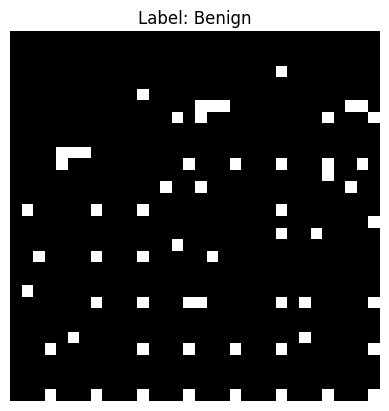

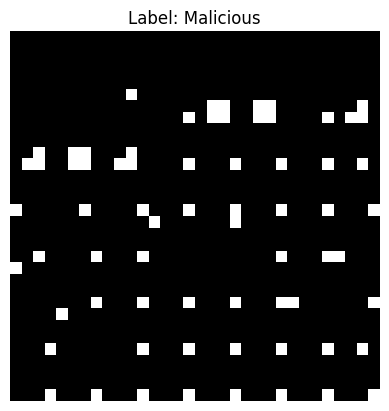

In [34]:
# plot a benign image
def plot_image(image, label):
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()


benign_image = train_dataset[0][0]
plot_image(benign_image, "Benign")

malicious_image = train_dataset[-1][0]
plot_image(malicious_image, "Malicious")

In [35]:
# computer class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_df_encoded["Label"]), y=train_df_encoded["Label"])
class_weights

array([0.6, 3. ])

In [52]:
model_savepath = f"../models/checkpoints/cnn/"
os.makedirs(model_savepath, exist_ok=True)





pathname_map = {
    'BinaryCNN': "bcnn",
    'BinaryCNN3': "bcnn3",
    'BinaryCNN2': "bcnn2"
}


benign_count = train_df_encoded["Label"].value_counts()[1]
malicious_count = train_df_encoded["Label"].value_counts().sum() - benign_count

pos_weight = torch.tensor([malicious_count / benign_count], dtype=torch.float32).to(device)

total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

pos_weight,

(tensor([5.], device='cuda:0'),)

In [69]:
best_stats = {
    "bcnn" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn2" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn3" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    }
}


for model_class in [BinaryCNN3]:
    model_name = model_class.__name__

    model_savepath_cosine = f"{model_savepath}{pathname_map[model_name]}_bce_cosine.pt"
    model_savepath_plateau = f"{model_savepath}{pathname_map[model_name]}_bce_plateau.pt"

    # print(f"Training {model_name} with CosineAnnealingWarmRestarts")
    # best_model_cos, history_cos = train_model_cosine(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=20, device=device, weights=class_weights, model_savepath=model_savepath_cosine, debug=False)
    # best_stats[pathname_map[model_name]]["cos"]["model"] = best_model_cos
    # best_stats[pathname_map[model_name]]["cos"]["history"] = history_cos
    # print("\n\n")

    # print(f"Training {model_name} with ReduceLROnPlateau")
    # best_model_plateau, history_plateau = train_model_reduceonplateau(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=20, device=device, weights=class_weights, model_savepath=model_savepath_plateau, debug=False)
    # best_stats[pathname_map[model_name]]["plateau"]["model"] = best_model_plateau
    # best_stats[pathname_map[model_name]]["plateau"]["history"] = history_plateau
    # print("\n\n")

    print(f"Training {model_name} with CosineAnnealingWarmRestarts")
    best_model_cos, history_cos = train_model_cosine(model_class, criterion_logits, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=20, device=device, pos_weights=pos_weight, model_savepath=model_savepath_cosine, debug=False)
    best_stats[pathname_map[model_name]]["cos"]["model"] = best_model_cos
    best_stats[pathname_map[model_name]]["cos"]["history"] = history_cos
    print("\n\n")

    print(f"Training {model_name} with ReduceLROnPlateau")
    best_model_plateau, history_plateau = train_model_reduceonplateau(model_class, criterion_logits, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=20, device=device, pos_weights=pos_weight, model_savepath=model_savepath_plateau, debug=False)
    best_stats[pathname_map[model_name]]["plateau"]["model"] = best_model_plateau
    best_stats[pathname_map[model_name]]["plateau"]["history"] = history_plateau
    print("\n\n")
    

Training BinaryCNN3 with CosineAnnealingWarmRestarts

Epoch 1/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:29<00:00, 25.72it/s]



Loss - Train: 0.5932, Val: 0.4290
Accuracy - Train: 0.8518, Val: 0.8432

Epoch 2/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:30<00:00, 25.00it/s]



Loss - Train: 0.4417, Val: 0.4531
Accuracy - Train: 0.8896, Val: 0.8343

Epoch 3/50
--------------------------------------------------


...


Loss - Train: 0.2963, Val: 0.4332
Accuracy - Train: 0.9182, Val: 0.8560

Epoch 49/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:28<00:00, 25.98it/s]



Loss - Train: 0.2913, Val: 0.4396
Accuracy - Train: 0.9180, Val: 0.8580

Epoch 50/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:29<00:00, 25.46it/s]



Loss - Train: 0.2950, Val: 0.4333
Accuracy - Train: 0.9164, Val: 0.8568

Best model was from epoch 39 with validation loss 0.4233





Model: bcnn3
CosineAnnealingWarmRestarts


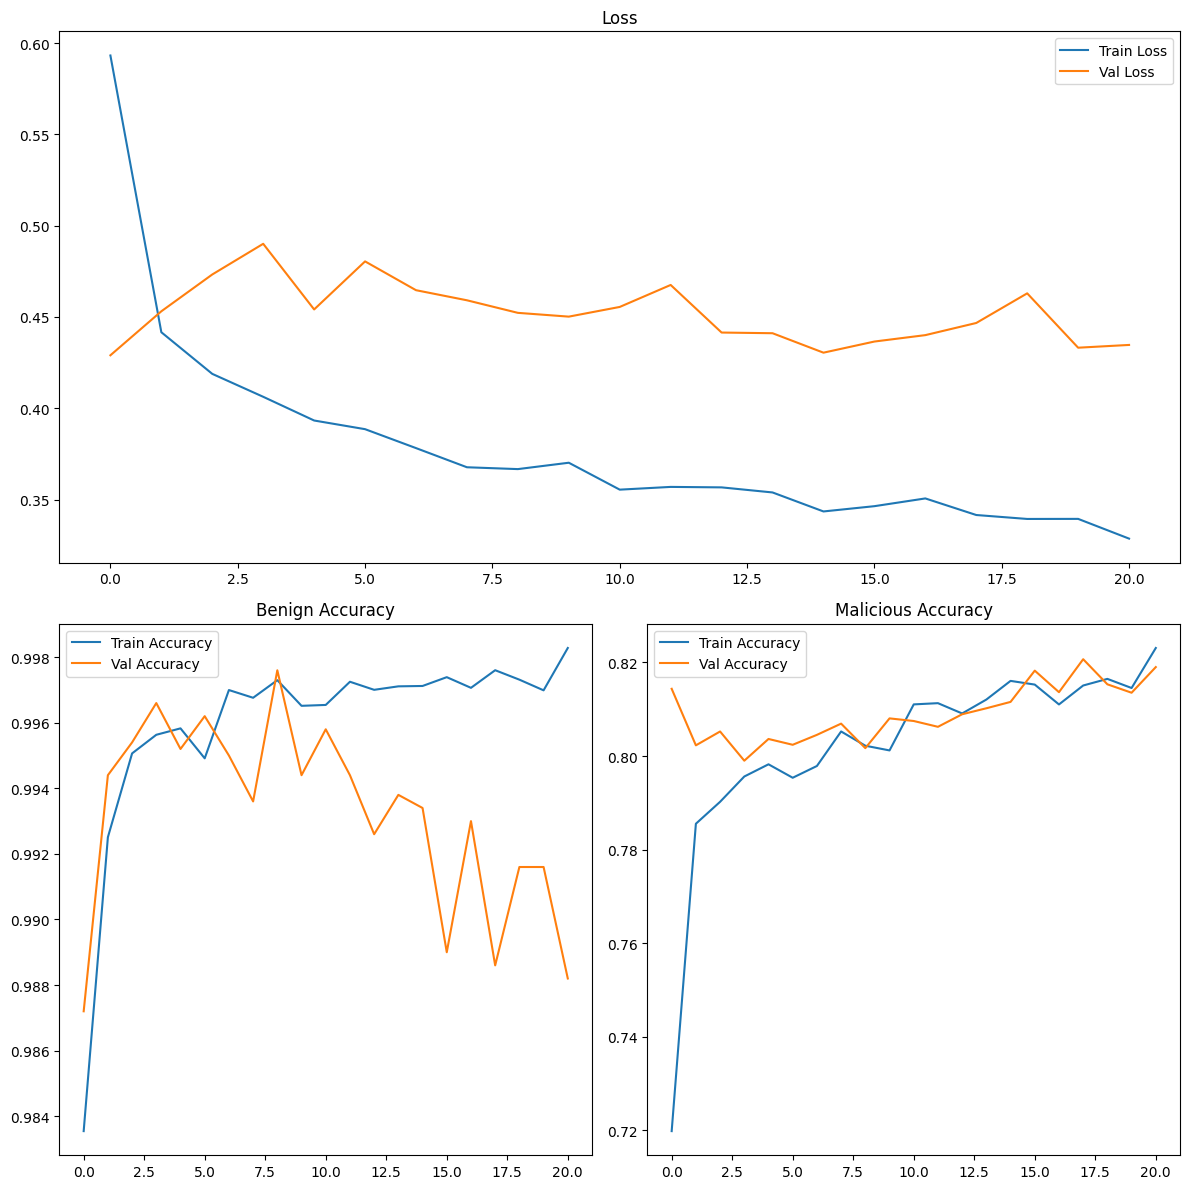

ReduceLROnPlateau


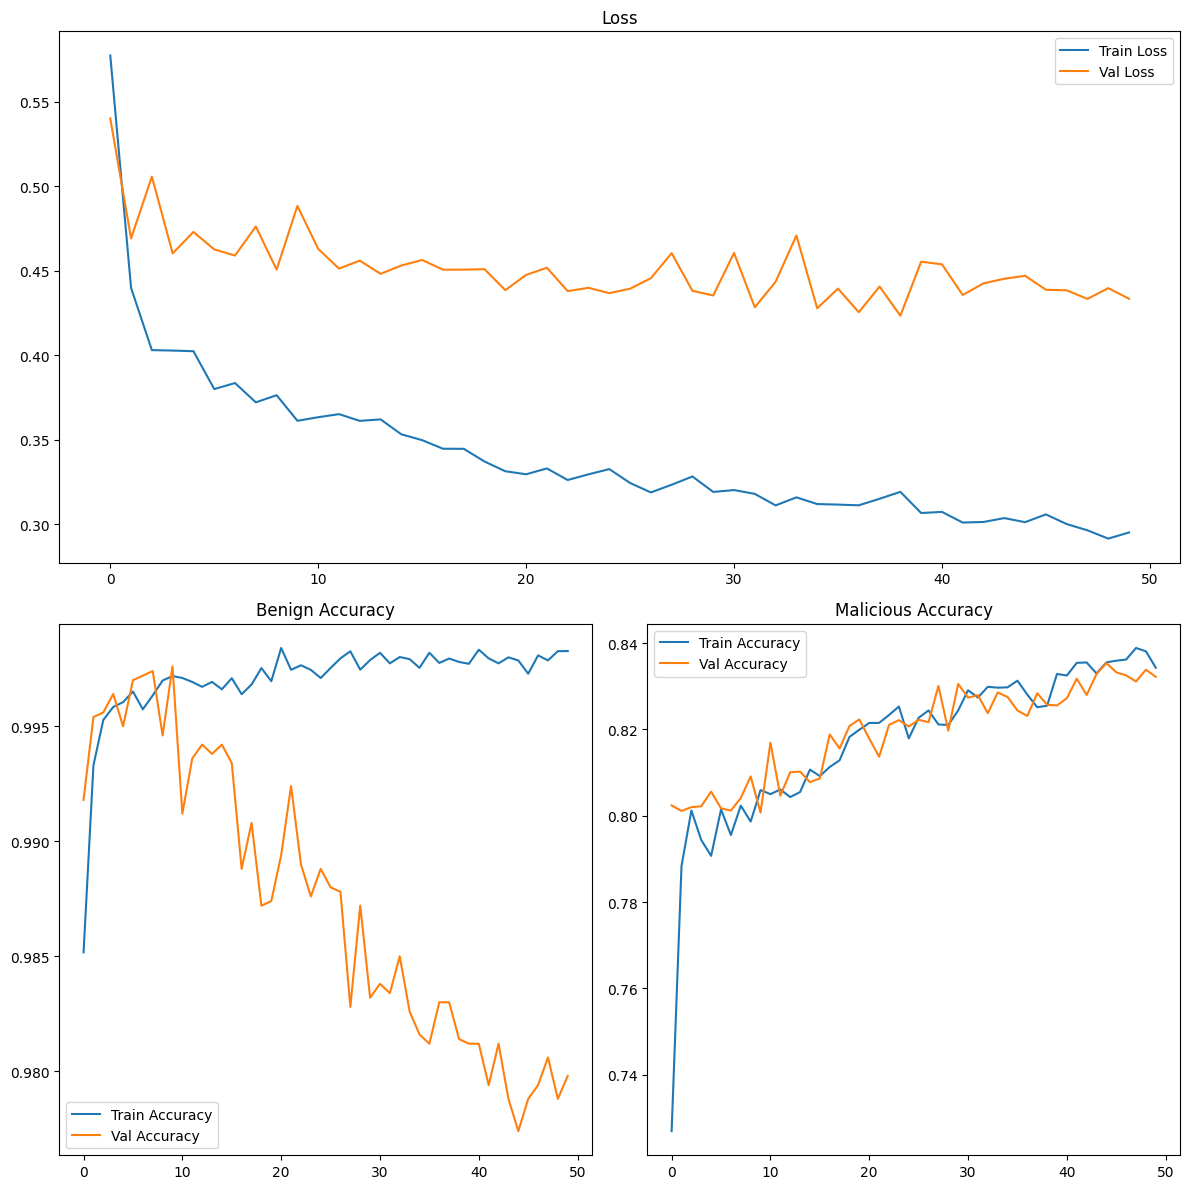

In [74]:
# plot metrics for each model
for model_name, model_stats in best_stats.items():

    if model_name != "bcnn3":
        continue
    
    print(f"Model: {model_name}")
    print("CosineAnnealingWarmRestarts")
    plot_metrics(model_stats["cos"]["history"])
    print("ReduceLROnPlateau")
    plot_metrics(model_stats["plateau"]["history"])
    print("\n\n")

In [75]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

In [76]:
test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [81]:
from sklearn.metrics import confusion_matrix

def test_model(model, test_dataloader, loss_class, device="cuda", return_probs=False):
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_true = []
    all_probs = []
    
    # Initialize criterion based on loss class
    if loss_class == nn.BCEWithLogitsLoss:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    elif loss_class == nn.CrossEntropyLoss:
        criterion = nn.CrossEntropyLoss()
    else:
        raise ValueError("Unsupported loss class")

    with torch.no_grad():
        for images, labels in tqdm(test_dataloader, desc="Testing Batches"):
            # Move data to device and format labels
            images = images.to(device)
            
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)  # CrossEntropy needs long labels
            else:
                labels = labels.float().to(device)  # BCE needs float labels

            outputs = model(images)
            outputs = outputs.squeeze(-1)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Calculate probabilities and predictions
            if loss_class == nn.CrossEntropyLoss:
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
            else:
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).int().squeeze()

            # Store results
            all_true.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    test_loss /= len(test_dataloader)
    metrics = calculate_class_metrics(all_true, all_preds)

    print(f"\nTest Loss: {test_loss:.4f}")
    print("Benign Metrics:")
    print(f"Accuracy: {metrics['benign']['accuracy']:.4f}, Precision: {metrics['benign']['precision']:.4f}, Recall: {metrics['benign']['recall']:.4f}, F1: {metrics['benign']['f1']:.4f}")
    print("Malicious Metrics:")
    print(f"Accuracy: {metrics['malicious']['accuracy']:.4f}, Precision: {metrics['malicious']['precision']:.4f}, Recall: {metrics['malicious']['recall']:.4f}, F1: {metrics['malicious']['f1']:.4f}")
    print(f"Overall Accuracy: {metrics['overall_accuracy']:.4f}")

    if return_probs:
        return {
            'loss': test_loss,
            'metrics': metrics,
            'true_labels': np.array(all_true),
            'pred_labels': np.array(all_preds),
            'probabilities': np.array(all_probs)
        }
    return {
        'loss': test_loss,
        'metrics': metrics,
        'true_labels': np.array(all_true),
        'pred_labels': np.array(all_preds)
    }

def test_metrics(true, preds):
    accuracy, precision, recall, f1 = calculate_metrics(true, preds)
    
    # confusion matrix
    cm = confusion_matrix(true, preds)

    # plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title("Confusion Matrix")

    plt.colorbar()

    # 1 is benign, 0 is malicious in predictions and labels

    
    plt.xticks([0, 1], ["Malicious", "Benign"])
    plt.yticks([0, 1], ["Malicious", "Benign"])


    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='red')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")



    plt.show()

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1


In [79]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

Testing BinaryCNN3 with CosineAnnealingWarmRestarts


Testing Batches: 100%|██████████| 300/300 [00:16<00:00, 18.65it/s]



Test Loss: 0.2458
Benign Metrics:
Accuracy: 0.9885, Precision: 0.9293, Recall: 0.9885, F1: 0.9580
Malicious Metrics:
Accuracy: 0.9248, Precision: 0.9877, Recall: 0.9248, F1: 0.9552
Overall Accuracy: 0.9567


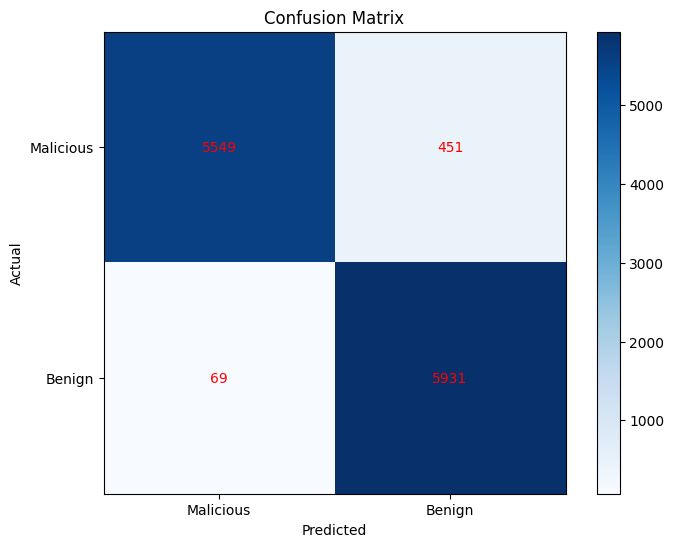

Accuracy: 0.9567
Precision: 0.9567
Recall: 0.9567
F1 Score: 0.9567



Testing BinaryCNN3 with ReduceLROnPlateau


Testing Batches: 100%|██████████| 300/300 [00:09<00:00, 30.03it/s]



Test Loss: 0.2941
Benign Metrics:
Accuracy: 0.9808, Precision: 0.9338, Recall: 0.9808, F1: 0.9568
Malicious Metrics:
Accuracy: 0.9305, Precision: 0.9798, Recall: 0.9305, F1: 0.9545
Overall Accuracy: 0.9557


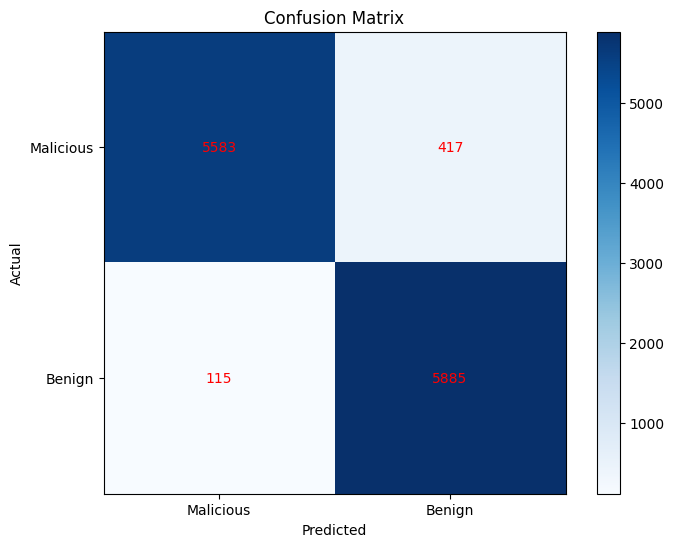

Accuracy: 0.9557
Precision: 0.9557
Recall: 0.9557
F1 Score: 0.9557





In [82]:
# model = BinaryCNN2().to(device)
# model.load_state_dict(torch.load(model_savepath, weights_only=True))


# test each model with the test data
# load model from checkpoint
# calculate metrics for each model

for model_class in [BinaryCNN3]:
    model_name = model_class.__name__
    print(f"Testing {model_name} with CosineAnnealingWarmRestarts")
    model = model_class().to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["cos"]["model"])
    test_results = test_model(model, test_data_loader_sample, criterion_logits, device=device)
    test_metrics(test_results["true_labels"], test_results["pred_labels"])
    print("\n\n")

    print(f"Testing {model_name} with ReduceLROnPlateau")
    model = model_class().to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["plateau"]["model"])
    test_results = test_model(model, test_data_loader_sample, criterion_logits, device=device)
    test_metrics(test_results["true_labels"], test_results["pred_labels"])
    print("\n\n")

    